# <center>Problem Statement</center>

The goal of this project is to analyze the factors that influence medical insurance costs for individuals. Insurance charges are an important indicator of health risk and financial planning, and they are affected by multiple factors such as age, gender, body mass index (BMI), smoking habits, number of dependents, and region of residence.

In this project, we aim to build a machine learning regression model to predict insurance costs based on demographic, health, and lifestyle indicators. Additionally, exploratory data analysis (EDA) will be performed to understand the relationships between these factors and insurance charges.

The insights obtained from this analysis can help insurance companies price policies accurately, identify high-risk groups, and assist individuals in planning their healthcare expenditures.

# <center>Data Overview</center>

The dataset contains individual-level demographic, health, and lifestyle information relevant to medical insurance.

The dataset consists of 1338 observations and 7 features, where each row represents an individual with associated insurance charges.

The target variable for this project is charges, which represents the medical insurance cost for an individual.

The features in the dataset include variables such as:

- Age – Age of the individual in years
- Sex – Gender of the individual (male/female)
- BMI – Body Mass Index (kg/m²)
- Children – Number of dependents
- Smoker – Smoking status (yes/no)
- Region – Residential area (northeast, northwest, southeast, southwest)

These variables collectively help explain the differences in insurance costs across individuals and allow the model to capture patterns associated with higher or lower medical expenses.

# <center>Data Dictionary</center>
|Column|Description|
|---|---
|age|Age of the primary beneficiary|
|sex|Gender of the insurance policyholder (female/male)|
|bmi|Body Mass Index (kg/m²)|
|children|Number of dependents covered under the insurance|
|smoker|Smoking status (yes/no)|
|region|Residential area in the US (northeast, southeast, southwest, northwest)|
|charges|Individual medical costs billed by health insurance|

In [15]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.model_selection import train_test_split

In [16]:
# Impoting the dataset
df = pd.read_csv('Medical_Insurance_cost_prediction.csv')

In [17]:
# Checking first five rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [18]:
# Checking the shape of dataset
df.shape

(1338, 7)

# <center>Data Understanding</center>

In [19]:
# Checking the summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [20]:
# Checking the dtypes of columns
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [21]:
# Checking the statistical summary of numerical columns
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [22]:
# Checking the statistical summary of categorical variables
df.describe(exclude='number')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [23]:
# Checking the column names
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [24]:
# Checking the null values in columns
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [25]:
# Checking for duplicate records
df.duplicated().sum()

np.int64(1)

In [26]:
# Dropping duplicates rows
df.drop_duplicates(inplace=True)

In [27]:
# Creating a list of num_cols and cat_cols
num_cols = df.select_dtypes(include='number').columns.to_list()
cat_cols = df.select_dtypes(exclude='number').columns.to_list()
print(f"Total Numerical columns we have {len(num_cols)} i.e. {num_cols}")
print(f"Total Categorical columns we have {len(cat_cols)} i.e. {cat_cols}")

Total Numerical columns we have 4 i.e. ['age', 'bmi', 'children', 'charges']
Total Categorical columns we have 3 i.e. ['sex', 'smoker', 'region']


# <center>Univariate Analysis</center>

In [28]:
# Checking the unique categories in categorical columns
for col in cat_cols:
    print('--------------------------------------------')
    print(f'Column: {col}')
    print(f'Number of unique values: {df[col].nunique()}')
    print(df[col].value_counts().head(10))
print('--------------------------------------------')

--------------------------------------------
Column: sex
Number of unique values: 2
sex
male      675
female    662
Name: count, dtype: int64
--------------------------------------------
Column: smoker
Number of unique values: 2
smoker
no     1063
yes     274
Name: count, dtype: int64
--------------------------------------------
Column: region
Number of unique values: 4
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
--------------------------------------------


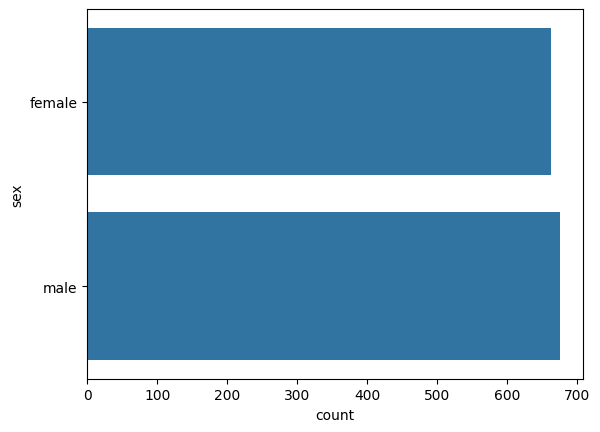

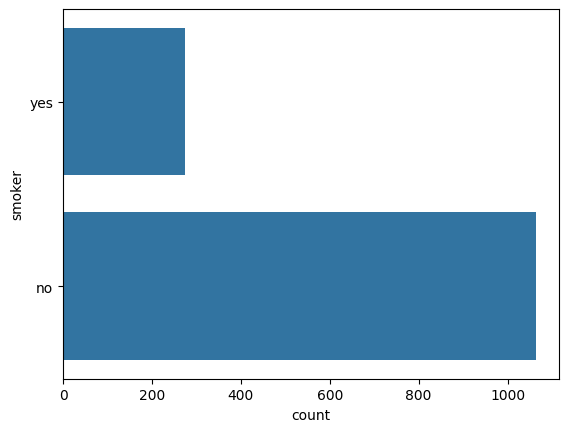

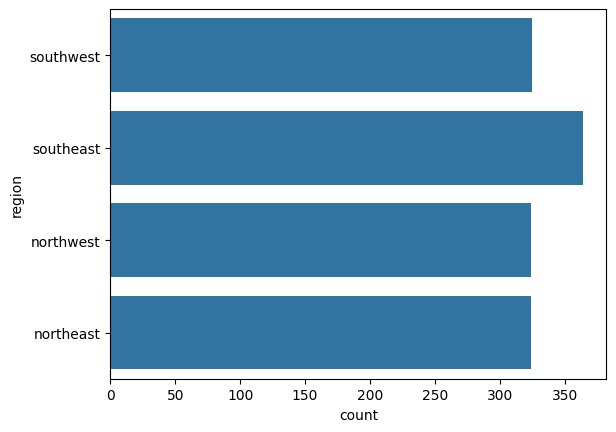

In [29]:
# Checking the countplot of categorical variables
for col in cat_cols:
    sns.countplot(df[col])
    plt.show()

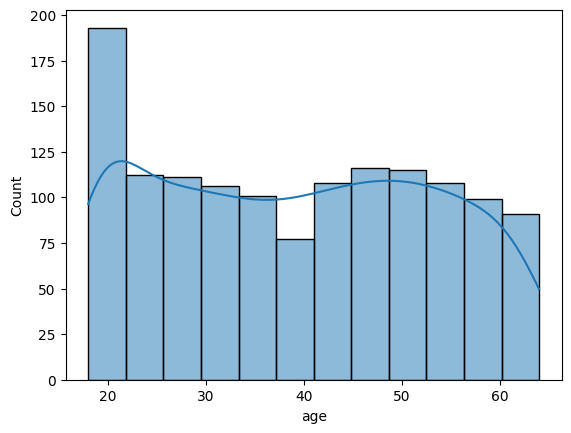

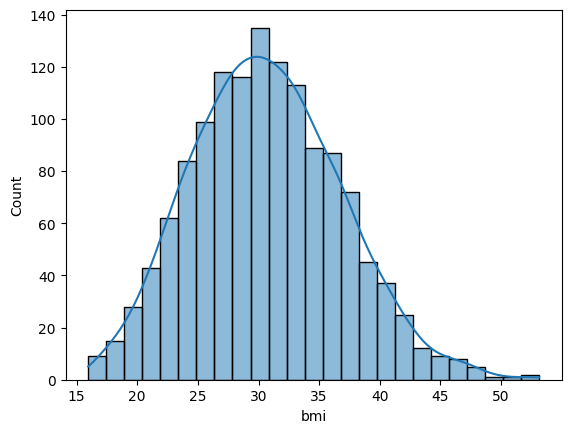

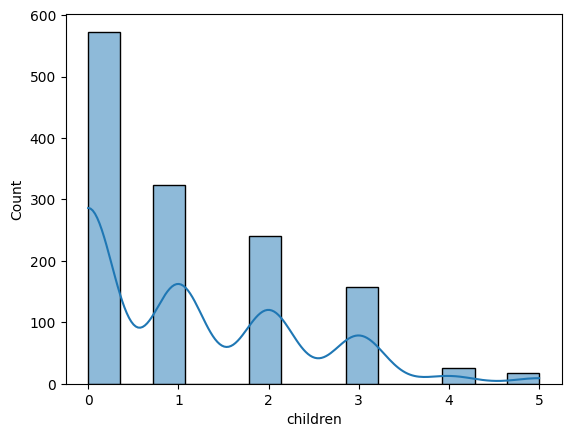

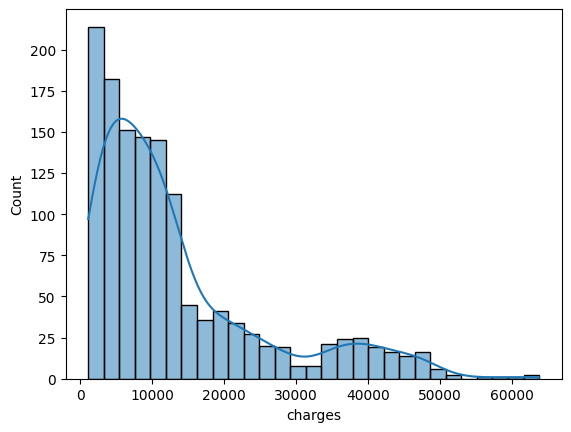

In [30]:
# Checking the distribution of numerical variables
for col in num_cols:
    sns.histplot(df[col],kde=True)
    plt.show()

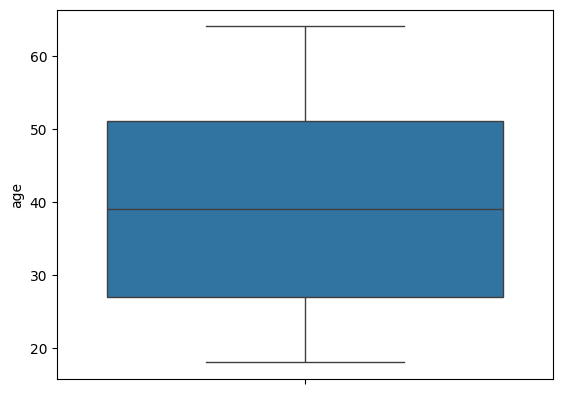

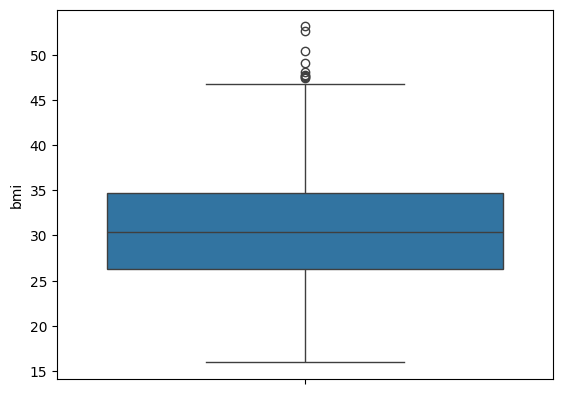

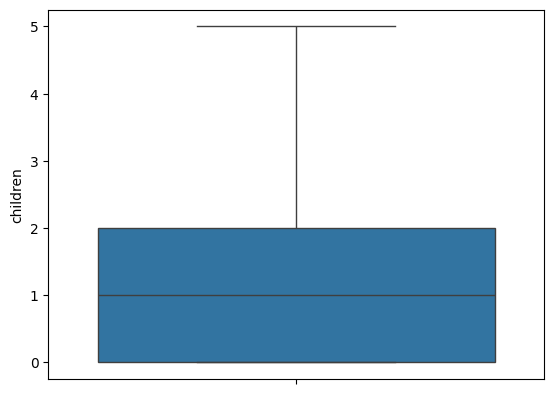

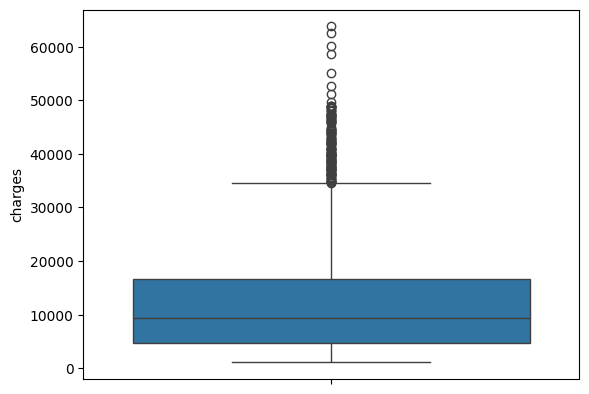

In [31]:
# Checking the outliers using Box plot
for col in num_cols:
    sns.boxplot(df[col])
    plt.show()

In [32]:
# Checking the skewness of numerical cols
df[num_cols].skew().sort_values(ascending=False)

charges     1.515391
children    0.937421
bmi         0.283914
age         0.054781
dtype: float64

# <center>Bivariate Analysis</center>

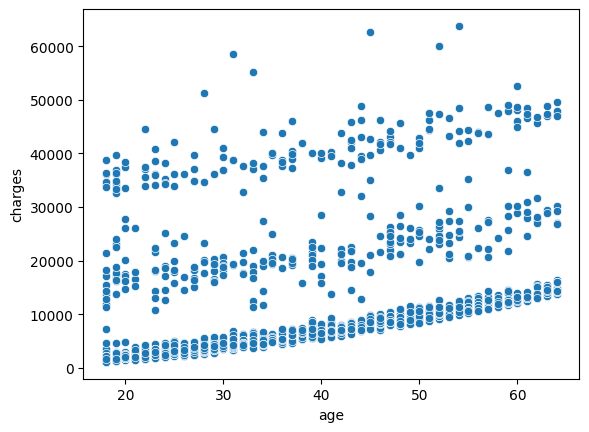

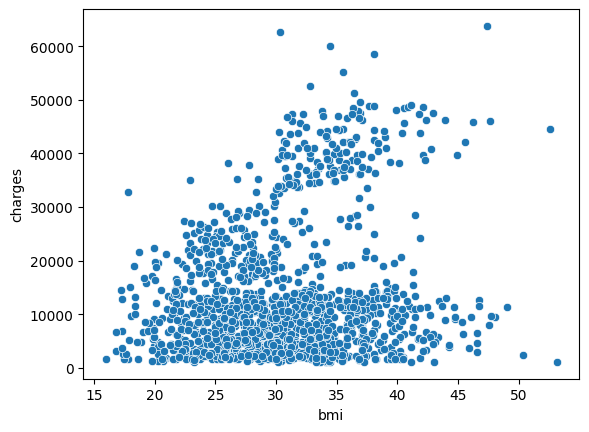

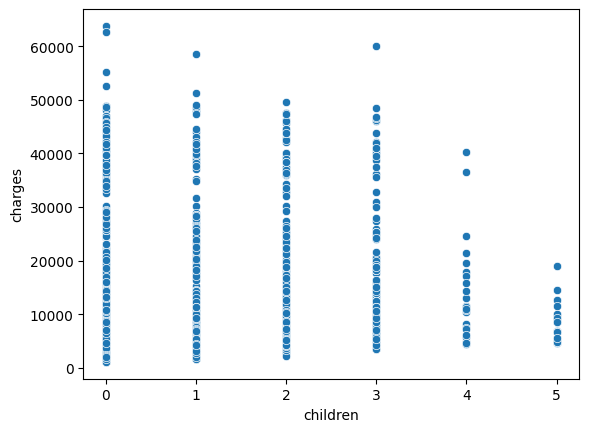

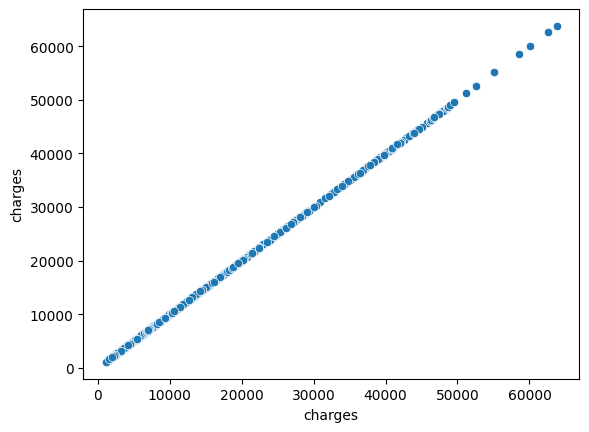

In [33]:
# Numerical Features Vs Numerical Target
for col in num_cols:
    sns.scatterplot(x=df[col], y=df['charges'])
    plt.show()

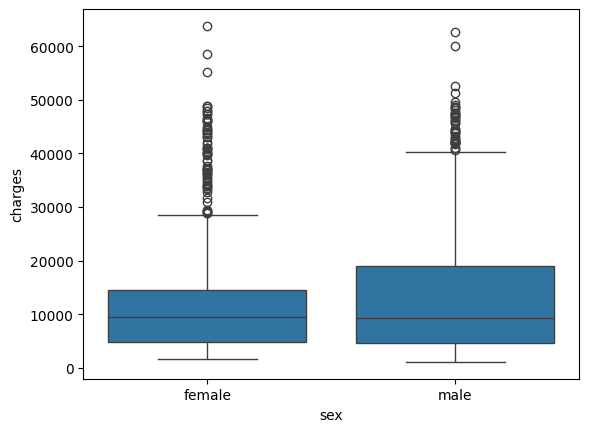

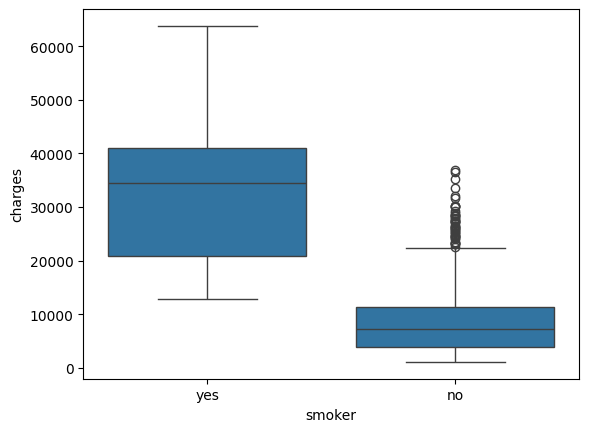

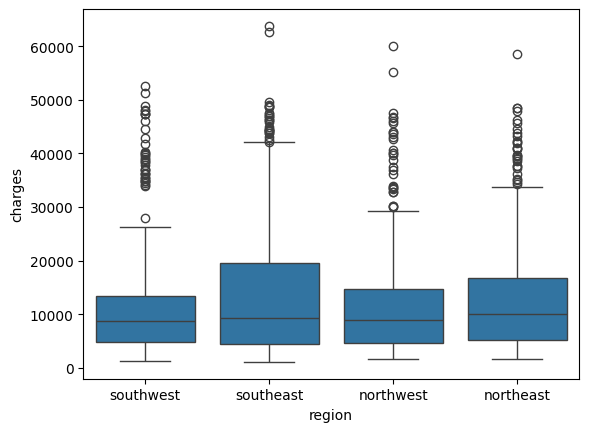

In [34]:
# Categorical features Vs Target Variable
for col in cat_cols:
    sns.boxplot(x=df[col], y=df['charges'])
    plt.show()

In [35]:
# Checking the correlation of numerical with target variable
corr_with_target = df.corr(numeric_only=True)['charges'].sort_values(ascending=False)
print(corr_with_target)

charges     1.000000
age         0.298308
bmi         0.198401
children    0.067389
Name: charges, dtype: float64


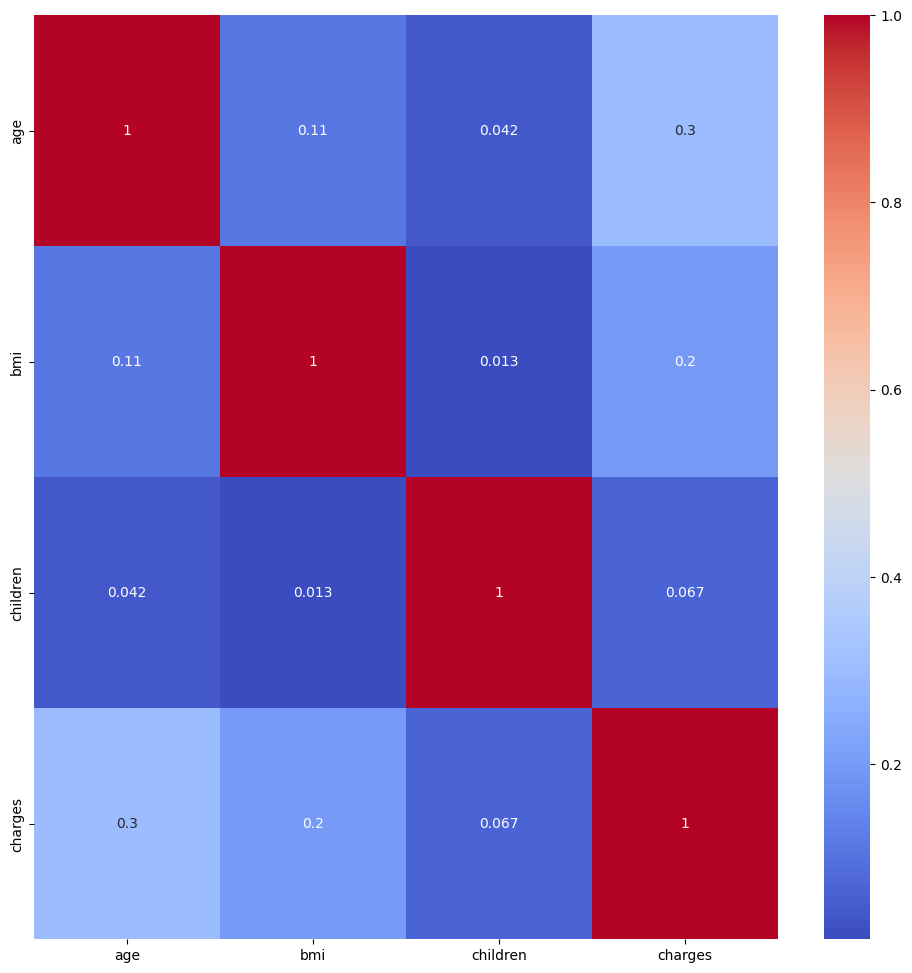

In [36]:
# Correlation Matrix
plt.figure(figsize=(12,12))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', annot=True)
plt.show()

# <center>TrainTest Split</center>

In [37]:
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# <center>Baseline Model</center>

In [38]:
# Baseline Models

from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
# Selecting the cat_cols and the num_cols
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

# Preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop = 'first', handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])

# Models
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "ElasticNet": ElasticNet(random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(random_state=42),
    "GradientBoost": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42)
}

# Baseline result
baseline_result = []

# Loop
for name, model in models.items():
    
    # pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Fit
    pipeline.fit(X_train, y_train)

    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Train metrics
    train_r2 = r2_score(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    
    # Test metrics
    test_r2 = r2_score(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    baseline_result.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Overfitting": "Yes" if (r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)) > 0.05 else "No"
    })
    

baseline_results_df = pd.DataFrame(baseline_result)
baseline_results_df = baseline_results_df.sort_values(by='Test R2', ascending=False)
baseline_results_df

,Model,Train R2,Test R2,Train MSE,Test MSE,Overfitting
9,GradientBoost,0.891603,0.901837,1.484109e+07,1.803805e+07,No
5,RandomForest,0.973651,0.879754,3.607513e+06,2.209599e+07,Yes
10,AdaBoost,0.828523,0.871113,2.347770e+07,2.368379e+07,No
8,XGBoost,0.995809,0.862827,5.738139e+05,2.520630e+07,Yes
4,DecisionTree,1.000000,0.818885,0.000000e+00,3.328099e+07,Yes
0,Linear,0.729906,0.806929,3.697986e+07,3.547802e+07,No
2,Lasso,0.729905,0.806858,3.697993e+07,3.549103e+07,No
1,Ridge,0.729884,0.805955,3.698281e+07,3.565688e+07,No
3,ElasticNet,0.374799,0.392868,8.559925e+07,1.115642e+08,No
6,KNN,0.442655,0.098077,7.630869e+07,1.657337e+08,Yes


In [39]:
# Baseline model with cross validaation

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor


# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Column Selection
num_cols = X_train.select_dtypes(exclude='object').columns
cat_cols = X_train.select_dtypes(include='object').columns

# Preprocessor (Baseline)
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])

# Models
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "ElasticNet": ElasticNet(random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "GradientBoost": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42)
}

# Evaluation Loop
cv_baseline_results = []

for name, model in models.items():
    
    # Create pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Cross Validation (Train + CV score)
    cv = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='r2',
        return_train_score=True,
        n_jobs=-1
    )
    
    # Fit on full training data
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Metrics
    cv_baseline_results.append({
        "Model": name,
        "Train R2 Mean": cv['train_score'].mean(),
        "Train R2 Std": cv['train_score'].std(),
        "Test R2 Mean": cv['test_score'].mean(),
        "Test R2 Std": cv['test_score'].std(),
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Train MSE": mean_squared_error(y_train, y_train_pred),
        "Test MSE": mean_squared_error(y_test, y_test_pred),
        "Overfitting": "Yes" if (r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)) > 0.05 else "No"
    })

# Results DataFrame
cv_baseline_results_df = pd.DataFrame(cv_baseline_results).sort_values(by="Test R2", ascending=False)
cv_baseline_results_df

,Model,Train R2 Mean,Train R2 Std,Test R2 Mean,Test R2 Std,Train R2,Test R2,Train MSE,Test MSE,Overfitting
9,GradientBoost,0.901747,0.004022,0.831145,0.014249,0.893225,0.900128,1.461905e+07,1.835208e+07,No
5,RandomForest,0.975205,0.001117,0.822298,0.007415,0.974299,0.882246,3.518843e+06,2.163793e+07,Yes
10,AdaBoost,0.814672,0.022597,0.791663,0.017926,0.829107,0.871295,2.339780e+07,2.365024e+07,No
8,XGBoost,0.997697,0.000279,0.794164,0.008608,0.995059,0.859983,6.765112e+05,2.572893e+07,Yes
0,Linear,0.730355,0.006395,0.725757,0.025277,0.729906,0.806929,3.697986e+07,3.547802e+07,No
2,Lasso,0.730355,0.006395,0.725770,0.025276,0.729906,0.806854,3.697989e+07,3.549173e+07,No
1,Ridge,0.730347,0.006395,0.725820,0.025268,0.729900,0.806448,3.698060e+07,3.556637e+07,No
4,DecisionTree,1.000000,0.000000,0.664023,0.046575,1.000000,0.798368,0.000000e+00,3.705118e+07,Yes
3,ElasticNet,0.499639,0.006801,0.497516,0.024733,0.499412,0.518956,6.853778e+07,8.839480e+07,No
6,KNN,0.497946,0.009395,0.218349,0.061444,0.522309,0.224983,6.540293e+07,1.424141e+08,Yes


|Metrics|Explanation |
|---|---
|Train R² Mean| Average training performance across cross-validation folds|
|Train R² Std| Standard deviation of training scores across folds|
|Test R² Mean (CV R²)|Average validation performance across folds|
|Test R² Std|Variation in validation scores across folds|
|Train R² (Full)|Model performance on entire training dataset (after final fit)|
|Test R² (Final)|Performance on completely unseen test data|
|Train MSE|Error on training data|
|Test MSE|Error on unseen data|

# <center>Model Improvement</center>

In [40]:
# Preprocessing for Linear Regression, Ridge, Lasso, Elastic Net

from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Columns Selection
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

skeweness = X_train[num_cols].skew()
skewed_cols = skeweness[abs(skeweness)>0.5].index.to_list()
non_skewed_cols = skeweness[abs(skeweness)<=0.5].index.to_list()

# skewed_cols preprocessing pipeline
skewed_pipeline = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('Scale', StandardScaler())
])

# non_skewed_cols preprocessing pipeline
non_skewed_pipeline = Pipeline([
    ('Scale', StandardScaler())
])

# for avoiding empty column issues for preprocessor
transformers=[]

if len(cat_cols)>0:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols))

if len(skewed_cols)>0:
    transformers.append(('skewed_num', skewed_pipeline, skewed_cols))

if len(non_skewed_cols)>0:
    transformers.append(('non_skewed_num', non_skewed_pipeline, non_skewed_cols))

# preprocessor
preprocessor = ColumnTransformer(transformers)

# Models
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "ElasticNet": ElasticNet(random_state=42)
}

# Result
cv_preprocessed_linear_results = []


# Loop
for name, model in models.items():
    final_model=Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

    cv = cross_validate(
        final_model,
        X_train,
        y_train,
        cv=5,
        scoring='r2',
        return_train_score=True,
        n_jobs=-1
    )

    # fit
    final_model.fit(X_train, y_train)

    # predict
    y_test_pred = final_model.predict(X_test)
    y_train_pred = final_model.predict(X_train)

    # Metrics
    cv_preprocessed_linear_results.append({
        "Model": name,
        "Train R2 Mean": cv['train_score'].mean(),
        "Train R2 Std": cv['train_score'].std(),
        "Test R2 Mean": cv['test_score'].mean(),
        "Test R2 Std": cv['test_score'].std(),
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Train MSE": mean_squared_error(y_train, y_train_pred),
        "Test MSE": mean_squared_error(y_test, y_test_pred),
        "Overfitting": "Yes" if (r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)) > 0.05 else "No"
    })

cv_preprocessed_linear_results_df = pd.DataFrame(cv_preprocessed_linear_results).sort_values(by='Test R2', ascending=False)
cv_preprocessed_linear_results_df

,Model,Train R2 Mean,Train R2 Std,Test R2 Mean,Test R2 Std,Train R2,Test R2,Train MSE,Test MSE,Overfitting
0,Linear,0.730423,0.006143,0.725742,0.024154,0.729961,0.807088,3.697234e+07,3.544874e+07,No
2,Lasso,0.730423,0.006143,0.725756,0.024148,0.729961,0.807006,3.697237e+07,3.546390e+07,No
1,Ridge,0.730414,0.006143,0.725806,0.024124,0.729955,0.806574,3.697310e+07,3.554328e+07,No
3,ElasticNet,0.487394,0.005847,0.485921,0.020939,0.487159,0.491971,7.021540e+07,9.335332e+07,No


In [41]:
# Preprocessing for KNN, SVM

from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Columns Selection
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

skeweness = X_train[num_cols].skew()
skewed_cols = skeweness[abs(skeweness)>0.5].index.to_list()
non_skewed_cols = skeweness[abs(skeweness)<=0.5].index.to_list()

# skewed_cols preprocessing pipeline
skewed_pipeline = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('Scale', StandardScaler())
])

# non_skewed_cols preprocessing pipeline
non_skewed_pipeline = Pipeline([
    ('Scale', StandardScaler())
])

# for avoiding empty column issues for preprocessor
transformers=[]

if len(cat_cols)>0:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols))

if len(skewed_cols)>0:
    transformers.append(('skewed_num', skewed_pipeline, skewed_cols))

if len(non_skewed_cols)>0:
    transformers.append(('non_skewed_num', non_skewed_pipeline, non_skewed_cols))

# preprocessor
preprocessor = ColumnTransformer(transformers)

# Models
models = {
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

# Result
cv_preprocessed_sk_results = []


# Loop
for name, model in models.items():
    final_model = TransformedTargetRegressor(
        regressor=Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ]),
        func = np.log1p,
        inverse_func = np.expm1
    )

    cv = cross_validate(
        final_model,
        X_train,
        y_train,
        cv=5,
        scoring='r2',
        return_train_score=True,
        n_jobs=-1
    )

    # fit
    final_model.fit(X_train, y_train)

    # predict
    y_test_pred = final_model.predict(X_test)
    y_train_pred = final_model.predict(X_train)

    # Metrics
    cv_preprocessed_sk_results.append({
        "Model": name,
        "Train R2 Mean": cv['train_score'].mean(),
        "Train R2 Std": cv['train_score'].std(),
        "Test R2 Mean": cv['test_score'].mean(),
        "Test R2 Std": cv['test_score'].std(),
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Train MSE": mean_squared_error(y_train, y_train_pred),
        "Test MSE": mean_squared_error(y_test, y_test_pred),
        "Overfitting": "Yes" if (r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)) > 0.05 else "No"
    })

cv_preprocessed_sk_results_df = pd.DataFrame(cv_preprocessed_sk_results).sort_values(by='Test R2', ascending=False)
cv_preprocessed_sk_results_df

,Model,Train R2 Mean,Train R2 Std,Test R2 Mean,Test R2 Std,Train R2,Test R2,Train MSE,Test MSE,Overfitting
1,SVR,0.835783,0.008368,0.805391,0.029832,0.835642,0.862125,2.250300e+07,2.533535e+07,No
0,KNN,0.765620,0.012764,0.653699,0.065458,0.789821,0.728952,2.877663e+07,4.980668e+07,Yes


In [42]:
# preprocessing for tree based models

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Columns Selection
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

# for avoiding empty column issues for preprocessor
transformers=[]

if len(cat_cols)>0:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols))

if len(num_cols)>0:
    transformers.append(('num', 'passthrough', num_cols))

# preprocessor
preprocessor = ColumnTransformer(transformers)

# Models
models = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "GradientBoost": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42)
}

# Result
cv_preprocessed_tree_results = []


# Loop
for name, model in models.items():
    final_model=Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

    cv = cross_validate(
        final_model,
        X_train,
        y_train,
        cv=5,
        scoring='r2',
        return_train_score=True,
        n_jobs=-1
    )

    # fit
    final_model.fit(X_train, y_train)

    # predict
    y_test_pred = final_model.predict(X_test)
    y_train_pred = final_model.predict(X_train)

    # Metrics
    cv_preprocessed_tree_results.append({
        "Model": name,
        "Train R2 Mean": cv['train_score'].mean(),
        "Train R2 Std": cv['train_score'].std(),
        "Test R2 Mean": cv['test_score'].mean(),
        "Test R2 Std": cv['test_score'].std(),
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Train MSE": mean_squared_error(y_train, y_train_pred),
        "Test MSE": mean_squared_error(y_test, y_test_pred),
        "Overfitting": "Yes" if (r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)) > 0.05 else "No"
    })

cv_preprocessed_tree_results_df = pd.DataFrame(cv_preprocessed_tree_results).sort_values(by='Test R2', ascending=False)
cv_preprocessed_tree_results_df

,Model,Train R2 Mean,Train R2 Std,Test R2 Mean,Test R2 Std,Train R2,Test R2,Train MSE,Test MSE,Overfitting
3,GradientBoost,0.901747,0.004022,0.831145,0.014249,0.893225,0.900128,1.461905e+07,1.835208e+07,No
1,RandomForest,0.975205,0.001117,0.822298,0.007415,0.974299,0.882246,3.518843e+06,2.163793e+07,Yes
4,AdaBoost,0.814672,0.022597,0.791663,0.017926,0.829107,0.871295,2.339780e+07,2.365024e+07,No
2,XGBoost,0.997697,0.000279,0.794164,0.008608,0.995059,0.859983,6.765112e+05,2.572893e+07,Yes
0,DecisionTree,1.000000,0.000000,0.664023,0.046575,1.000000,0.798368,0.000000e+00,3.705118e+07,Yes


In [43]:
# combined results preprocessed only
crpo = pd.concat([cv_preprocessed_tree_results_df, cv_preprocessed_sk_results_df, cv_preprocessed_linear_results_df])
crpo.sort_values(by='Test R2', ascending=False, inplace=True)
crpo

,Model,Train R2 Mean,Train R2 Std,Test R2 Mean,Test R2 Std,Train R2,Test R2,Train MSE,Test MSE,Overfitting
3,GradientBoost,0.901747,0.004022,0.831145,0.014249,0.893225,0.900128,1.461905e+07,1.835208e+07,No
1,RandomForest,0.975205,0.001117,0.822298,0.007415,0.974299,0.882246,3.518843e+06,2.163793e+07,Yes
4,AdaBoost,0.814672,0.022597,0.791663,0.017926,0.829107,0.871295,2.339780e+07,2.365024e+07,No
1,SVR,0.835783,0.008368,0.805391,0.029832,0.835642,0.862125,2.250300e+07,2.533535e+07,No
2,XGBoost,0.997697,0.000279,0.794164,0.008608,0.995059,0.859983,6.765112e+05,2.572893e+07,Yes
0,Linear,0.730423,0.006143,0.725742,0.024154,0.729961,0.807088,3.697234e+07,3.544874e+07,No
2,Lasso,0.730423,0.006143,0.725756,0.024148,0.729961,0.807006,3.697237e+07,3.546390e+07,No
1,Ridge,0.730414,0.006143,0.725806,0.024124,0.729955,0.806574,3.697310e+07,3.554328e+07,No
0,DecisionTree,1.000000,0.000000,0.664023,0.046575,1.000000,0.798368,0.000000e+00,3.705118e+07,Yes
0,KNN,0.765620,0.012764,0.653699,0.065458,0.789821,0.728952,2.877663e+07,4.980668e+07,Yes


In [44]:
# Preprocessing + Hyperparameter Tuning for Linear Regression, Ridge, Lasso, Elastic Net

from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Columns Selection
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

skeweness = X_train[num_cols].skew()
skewed_cols = skeweness[abs(skeweness)>0.5].index.to_list()
non_skewed_cols = skeweness[abs(skeweness)<=0.5].index.to_list()

# skewed_cols preprocessing pipeline
skewed_pipeline = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

# non_skewed_cols preprocessing pipeline
non_skewed_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# for avoiding empty column issues for preprocessor
transformers=[]

if len(cat_cols)>0:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols))

if len(skewed_cols)>0:
    transformers.append(('skewed_num', skewed_pipeline, skewed_cols))

if len(non_skewed_cols)>0:
    transformers.append(('non_skewed_num', non_skewed_pipeline, non_skewed_cols))

# preprocessor
preprocessor = ColumnTransformer(transformers)

# Models
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "ElasticNet": ElasticNet(random_state=42)
}

grid_param = {
    "Linear": {
        "model__fit_intercept": [True, False]
    },
    "Ridge": {
        "model__alpha": [0.01, 0.1, 1, 10, 100],
        "model__fit_intercept": [True, False],
        "model__solver": ['auto', 'lsqr']
    },
    "Lasso": {
        "model__alpha": [0.001, 0.01, 0.1, 1],
        "model__fit_intercept": [True, False]
    },
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.1, 1],
        "model__l1_ratio": [0.2, 0.5, 0.7, 0.9],
        "model__fit_intercept": [True, False]
    }
}


# Result
tuned_cv_preprocessed_linear_params = {}
tuned_cv_preprocessed_linear_results = []


# Loop
for name, model in models.items():
    print(f"\n🔍 Training {name}...")

    final_model=Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
    
    grid = GridSearchCV(
        final_model,
        grid_param[name],
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )

    # fit
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    tuned_cv_preprocessed_linear_params[name]=best_model

    print("Best Params:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)
    

    # predict
    y_test_pred = best_model.predict(X_test)
    y_train_pred = best_model.predict(X_train)

    # Metrics
    tuned_cv_preprocessed_linear_results.append({
        "Model": name,
        "Best CV R2": grid.best_score_,
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Train MSE": mean_squared_error(y_train, y_train_pred),
        "Test MSE": mean_squared_error(y_test, y_test_pred),
        "Overfitting": "Yes" if (r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)) > 0.05 else "No"
    })

tuned_cv_preprocessed_linear_results_df = pd.DataFrame(tuned_cv_preprocessed_linear_results).sort_values(by='Test R2', ascending=False)
tuned_cv_preprocessed_linear_results_df


🔍 Training Linear...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best Params: {'model__fit_intercept': True}
Best CV Score: 0.7257424337320255

🔍 Training Ridge...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'model__alpha': 1, 'model__fit_intercept': False, 'model__solver': 'lsqr'}
Best CV Score: 0.7258383535726105

🔍 Training Lasso...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'model__alpha': 1, 'model__fit_intercept': True}
Best CV Score: 0.7257559526182635

🔍 Training ElasticNet...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Params: {'model__alpha': 0.01, 'model__fit_intercept': False, 'model__l1_ratio': 0.7}
Best CV Score: 0.7259039564298346


,Model,Best CV R2,Train R2,Test R2,Train MSE,Test MSE,Overfitting
0,Linear,0.725742,0.729961,0.807088,3.697234e+07,3.544874e+07,No
2,Lasso,0.725756,0.729961,0.807006,3.697237e+07,3.546390e+07,No
1,Ridge,0.725838,0.729948,0.806299,3.697407e+07,3.559375e+07,No
3,ElasticNet,0.725904,0.729832,0.804497,3.698992e+07,3.592485e+07,No


In [45]:
# Preprocessing + Hyperparameter Tuning for KNN, SVM

from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Columns Selection
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

skeweness = X_train[num_cols].skew()
skewed_cols = skeweness[abs(skeweness)>0.5].index.to_list()
non_skewed_cols = skeweness[abs(skeweness)<=0.5].index.to_list()

# skewed_cols preprocessing pipeline
skewed_pipeline = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

# non_skewed_cols preprocessing pipeline
non_skewed_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# for avoiding empty column issues for preprocessor
transformers=[]

if len(cat_cols)>0:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols))

if len(skewed_cols)>0:
    transformers.append(('skewed_num', skewed_pipeline, skewed_cols))

if len(non_skewed_cols)>0:
    transformers.append(('non_skewed_num', non_skewed_pipeline, non_skewed_cols))

# preprocessor
preprocessor = ColumnTransformer(transformers)

# Models
models = {
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

grid_param = {
    "KNN": {
    "regressor__model__n_neighbors": [3, 5, 7, 9, 11],
    "regressor__model__weights": ["uniform", "distance"],
    "regressor__model__metric": ["minkowski"],
    "regressor__model__p": [1, 2]
},
    "SVR": {
    "regressor__model__kernel": ["rbf"],
    "regressor__model__C": [0.1, 1, 10, 100],
    "regressor__model__epsilon": [0.01, 0.1, 0.5],
    "regressor__model__gamma": ["scale", "auto"]
}
}


# Result
tuned_cv_preprocessed_sk_params = {}
tuned_cv_preprocessed_sk_results = []


# Loop
for name, model in models.items():
    print(f"\n🔍 Training {name}...")

    final_model = TransformedTargetRegressor(
        regressor=Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ]),
        func = np.log1p,
        inverse_func = np.expm1
    )
    
    grid = GridSearchCV(
        final_model,
        grid_param[name],
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )

    # fit
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    tuned_cv_preprocessed_sk_params[name]=best_model

    print("Best Params:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)
    

    # predict
    y_test_pred = best_model.predict(X_test)
    y_train_pred = best_model.predict(X_train)

    # Metrics
    tuned_cv_preprocessed_sk_results.append({
        "Model": name,
        "Best CV R2": grid.best_score_,
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Train MSE": mean_squared_error(y_train, y_train_pred),
        "Test MSE": mean_squared_error(y_test, y_test_pred),
        "Overfitting": "Yes" if (r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)) > 0.05 else "No"
    })

tuned_cv_preprocessed_sk_results_df = pd.DataFrame(tuned_cv_preprocessed_sk_results).sort_values(by='Test R2', ascending=False)
tuned_cv_preprocessed_sk_results_df


🔍 Training KNN...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'regressor__model__metric': 'minkowski', 'regressor__model__n_neighbors': 5, 'regressor__model__p': 1, 'regressor__model__weights': 'distance'}
Best CV Score: 0.7360712115758888

🔍 Training SVR...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'regressor__model__C': 10, 'regressor__model__epsilon': 0.1, 'regressor__model__gamma': 'auto', 'regressor__model__kernel': 'rbf'}
Best CV Score: 0.8134487321400682


,Model,Best CV R2,Train R2,Test R2,Train MSE,Test MSE,Overfitting
1,SVR,0.813449,0.839447,0.887156,2.198205e+07,2.073582e+07,No
0,KNN,0.736071,1.000000,0.789153,8.787803e-23,3.874433e+07,Yes


In [46]:
# Preprocessing + Hyperparameter Tuning for tree based models


from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Columns Selection
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

# for avoiding empty column issues for preprocessor
transformers=[]

if len(cat_cols)>0:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols))

if len(num_cols)>0:
    transformers.append(('num', 'passthrough', num_cols))

# preprocessor
preprocessor = ColumnTransformer(transformers)

# Models
models = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "GradientBoost": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42)
}

grid_param = {
    "DecisionTree": {
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": [None, "sqrt", "log2"]
},
    "RandomForest": {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
},
    "XGBoost": {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.01, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__gamma": [0, 0.1, 0.2]
},
    "GradientBoost": {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__max_depth": [3, 5],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__subsample": [0.8, 1.0]
},
    "AdaBoost":{
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.1, 1]
}
}


# Result
tuned_cv_preprocessed_tree_params = {}
tuned_cv_preprocessed_tree_results = []


# Loop
for name, model in models.items():
    print(f"\n🔍 Training {name}...")

    final_model =Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
    
    grid = GridSearchCV(
        final_model,
        grid_param[name],
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )

    # fit
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    tuned_cv_preprocessed_tree_params[name]=best_model

    print("Best Params:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)
    

    # predict
    y_test_pred = best_model.predict(X_test)
    y_train_pred = best_model.predict(X_train)

    # Metrics
    tuned_cv_preprocessed_tree_results.append({
        "Model": name,
        "Best CV R2": grid.best_score_,
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Train MSE": mean_squared_error(y_train, y_train_pred),
        "Test MSE": mean_squared_error(y_test, y_test_pred),
        "Overfitting": "Yes" if (r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)) > 0.05 else "No"
    })

tuned_cv_preprocessed_tree_results_df = pd.DataFrame(tuned_cv_preprocessed_tree_results).sort_values(by='Test R2', ascending=False)
tuned_cv_preprocessed_tree_results_df


🔍 Training DecisionTree...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Params: {'model__max_depth': 5, 'model__max_features': None, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}
Best CV Score: 0.8284272278994331

🔍 Training RandomForest...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV Score: 0.8329117870903247

🔍 Training XGBoost...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best Params: {'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
Best CV Score: 0.8401469268074981

🔍 Training GradientBoost...
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples

,Model,Best CV R2,Train R2,Test R2,Train MSE,Test MSE,Overfitting
3,GradientBoost,0.838105,0.892668,0.901134,1.469529e+07,1.816723e+07,No
2,XGBoost,0.840147,0.882753,0.900173,1.605279e+07,1.834373e+07,No
0,DecisionTree,0.828427,0.866907,0.895525,1.822245e+07,1.919795e+07,No
4,AdaBoost,0.829948,0.849164,0.890650,2.065165e+07,2.009370e+07,No
1,RandomForest,0.832912,0.918944,0.882842,1.109776e+07,2.152855e+07,No


In [47]:
# BaggingRegressor full pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

# Columns Selection
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

# for avoiding empty column issues for preprocessor
transformers=[]

if len(cat_cols)>0:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols))

if len(num_cols)>0:
    transformers.append(('num', 'passthrough', num_cols))

# preprocessor
preprocessor = ColumnTransformer(transformers)

model = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=100,
    random_state=42
)

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_samples": [0.7, 0.8, 1.0],
    "model__max_features": [0.7, 0.8, 1.0],
    "model__bootstrap": [True],
    "model__estimator__max_depth": [3, 5, 7],
    "model__estimator__min_samples_split": [2, 5, 10]
}

tuned_cv_preprocessed_bagging_params={}
tuned_cv_preprocessed_bagging_results=[]

print(f"\n🔍 Training BaggingRegressor...")

final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

grid = GridSearchCV(
    final_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=True
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

tuned_cv_preprocessed_bagging_params["Bagging"]=best_model

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
    

# predict
y_test_pred = best_model.predict(X_test)
y_train_pred = best_model.predict(X_train)

# Metrics
tuned_cv_preprocessed_bagging_results.append({
    "Model": "Bagging",
    "Best CV R2": grid.best_score_,
    "Train R2": r2_score(y_train, y_train_pred),
    "Test R2": r2_score(y_test, y_test_pred),
    "Train MSE": mean_squared_error(y_train, y_train_pred),
    "Test MSE": mean_squared_error(y_test, y_test_pred),
    "Overfitting": "Yes" if (r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)) > 0.05 else "No"
    })

tuned_cv_preprocessed_bagging_results_df = pd.DataFrame(tuned_cv_preprocessed_bagging_results).sort_values(by='Test R2', ascending=False)
tuned_cv_preprocessed_bagging_results_df


🔍 Training BaggingRegressor...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Params: {'model__bootstrap': True, 'model__estimator__max_depth': 5, 'model__estimator__min_samples_split': 10, 'model__max_features': 1.0, 'model__max_samples': 0.7, 'model__n_estimators': 100}
Best CV Score: 0.8441084876248126


,Model,Best CV R2,Train R2,Test R2,Train MSE,Test MSE,Overfitting
0,Bagging,0.844108,0.877038,0.902252,1.683530e+07,1.796176e+07,No


In [48]:
# Voting Regressor with GridSearchCV

import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

from xgboost import XGBRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error



# Column Selection
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

# Preprocessing
transformers = []

if len(cat_cols) > 0:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols))

if len(num_cols) > 0:
    transformers.append(('num', 'passthrough', num_cols))

preprocessor = ColumnTransformer(transformers)

# Base Models
voting_model = VotingRegressor(
    estimators=[
        ('gb', GradientBoostingRegressor(random_state=42)),
        ('rf', RandomForestRegressor(random_state=42)),
        ('xgb', XGBRegressor(random_state=42, verbosity=0))
    ]
)

# Parameter Grid (IMPORTANT)
param_grid = {
    # Gradient Boosting
    "model__gb__n_estimators": [100, 200],
    "model__gb__learning_rate": [0.05, 0.1],

    # Random Forest
    "model__rf__n_estimators": [100, 200],
    "model__rf__max_depth": [None, 10],

    # XGBoost
    "model__xgb__n_estimators": [100, 200],
    "model__xgb__learning_rate": [0.05, 0.1],
    "model__xgb__max_depth": [3, 5],

    # Voting weights
    "model__weights": [
        [1,1,1],
        [2,1,1],
        [1,2,1],
        [1,1,2],
        [3,1,1]
    ]
}

tuned_cv_preprocessed_voting_params = {}

print(f"\n🔍 Training VotingRegressor...")

# Full Pipeline
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', voting_model)
])

# Grid Search
grid = GridSearchCV(
    final_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

tuned_cv_preprocessed_voting_params["Voting"]=best_model

print("Best Params:", grid.best_params_)
print("Best CV R2:", grid.best_score_)


# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Results
tuned_cv_preprocessed_voting_results_df = pd.DataFrame([{
    "Model": "Voting",
    "Best CV R2": grid.best_score_,
    "Train R2": r2_score(y_train, y_train_pred),
    "Test R2": r2_score(y_test, y_test_pred),
    "Train MSE": mean_squared_error(y_train, y_train_pred),
    "Test MSE": mean_squared_error(y_test, y_test_pred),
    "Overfitting": "Yes" if (r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)) > 0.05 else "No"
}])

tuned_cv_preprocessed_voting_results_df


🔍 Training VotingRegressor...
Fitting 5 folds for each of 640 candidates, totalling 3200 fits
Best Params: {'model__gb__learning_rate': 0.05, 'model__gb__n_estimators': 100, 'model__rf__max_depth': 10, 'model__rf__n_estimators': 100, 'model__weights': [1, 1, 2], 'model__xgb__learning_rate': 0.05, 'model__xgb__max_depth': 3, 'model__xgb__n_estimators': 100}
Best CV R2: 0.8437693798616298


,Model,Best CV R2,Train R2,Test R2,Train MSE,Test MSE,Overfitting
0,Voting,0.843769,0.902166,0.901105,1.339496e+07,1.817252e+07,No


In [49]:
# Stacking Regressor Full Pipeline

import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

from xgboost import XGBRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error


# Columns Selection
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()


# Preprocessing
transformers = []

if len(cat_cols) > 0:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols))

if len(num_cols) > 0:
    transformers.append(('num', 'passthrough', num_cols))

preprocessor = ColumnTransformer(transformers)


# Base Models
base_models = [
    ('gb', GradientBoostingRegressor(random_state=42)),
    ('rf', RandomForestRegressor(random_state=42)),
    ('xgb', XGBRegressor(random_state=42, verbosity=0))
]

# Hyperparameter Grid
param_grid = {
    # Gradient Boost
    "model__gb__n_estimators": [100, 200],
    "model__gb__learning_rate": [0.05, 0.1],
    
    # Random Forest
    "model__rf__n_estimators": [100, 200],
    "model__rf__max_depth": [None, 10],
    
    # XGBoost
    "model__xgb__n_estimators": [100, 200],
    "model__xgb__learning_rate": [0.05, 0.1],
    "model__xgb__max_depth": [3, 5],
    
    # Meta Model (Ridge)
    "model__final_estimator__alpha": [0.1, 1, 10]
}

tuned_cv_preprocessed_stacking_params={}

print(f"\n🔍 Training StackingRegressor...")

# Final Model
final_estimator = Ridge()

# Stacking Model
stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=final_estimator,
    n_jobs=-1
)

# Full Pipeline
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', stack_model)
])

# Grid Search
grid = GridSearchCV(
    final_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

tuned_cv_preprocessed_stacking_params["Stacking"]=best_model

print("Best Params:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Metrics
tuned_cv_preprocessed_stacking_results_df = pd.DataFrame([{
    "Model": "Stacking",
    "Best CV R2": grid.best_score_,
    "Train R2": r2_score(y_train, y_train_pred),
    "Test R2": r2_score(y_test, y_test_pred),
    "Train MSE": mean_squared_error(y_train, y_train_pred),
    "Test MSE": mean_squared_error(y_test, y_test_pred),
    "Overfitting": "Yes" if (r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)) > 0.05 else "No"
}])

tuned_cv_preprocessed_stacking_results_df


🔍 Training StackingRegressor...
Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Best Params: {'model__final_estimator__alpha': 0.1, 'model__gb__learning_rate': 0.1, 'model__gb__n_estimators': 200, 'model__rf__max_depth': 10, 'model__rf__n_estimators': 100, 'model__xgb__learning_rate': 0.05, 'model__xgb__max_depth': 3, 'model__xgb__n_estimators': 100}
Best CV R2: 0.8459363640646849


,Model,Best CV R2,Train R2,Test R2,Train MSE,Test MSE,Overfitting
0,Stacking,0.845936,0.864677,0.902442,1.852769e+07,1.792687e+07,No


In [50]:
# combined result preprocessed + tuned
crpt = pd.concat([
    tuned_cv_preprocessed_linear_results_df, 
    tuned_cv_preprocessed_sk_results_df, 
    tuned_cv_preprocessed_tree_results_df, 
    tuned_cv_preprocessed_stacking_results_df, 
    tuned_cv_preprocessed_voting_results_df, 
    tuned_cv_preprocessed_bagging_results_df
]).sort_values(by='Test R2', ascending=False)
crpt

,Model,Best CV R2,Train R2,Test R2,Train MSE,Test MSE,Overfitting
0,Stacking,0.845936,0.864677,0.902442,1.852769e+07,1.792687e+07,No
0,Bagging,0.844108,0.877038,0.902252,1.683530e+07,1.796176e+07,No
3,GradientBoost,0.838105,0.892668,0.901134,1.469529e+07,1.816723e+07,No
0,Voting,0.843769,0.902166,0.901105,1.339496e+07,1.817252e+07,No
2,XGBoost,0.840147,0.882753,0.900173,1.605279e+07,1.834373e+07,No
0,DecisionTree,0.828427,0.866907,0.895525,1.822245e+07,1.919795e+07,No
4,AdaBoost,0.829948,0.849164,0.890650,2.065165e+07,2.009370e+07,No
1,SVR,0.813449,0.839447,0.887156,2.198205e+07,2.073582e+07,No
1,RandomForest,0.832912,0.918944,0.882842,1.109776e+07,2.152855e+07,No
0,Linear,0.725742,0.729961,0.807088,3.697234e+07,3.544874e+07,No


In [51]:
# Best performance model
best_model_name = crpt.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Stacking


In [52]:
# All best models
all_models = {**tuned_cv_preprocessed_linear_params, **tuned_cv_preprocessed_sk_params, **tuned_cv_preprocessed_tree_params, **tuned_cv_preprocessed_bagging_params, **tuned_cv_preprocessed_stacking_params, **tuned_cv_preprocessed_voting_params}
all_models


{'Linear': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['sex', 'smoker', 'region']),
                                                  ('skewed_num',
                                                   Pipeline(steps=[('power',
                                                                    PowerTransformer()),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['children']),
                                                  ('non_skewed_num',
                                                   Pipeline(steps=[('scaler',
                                                                    StandardScaler())]),
                          

# <center>Final Model</center>

In [53]:
# Final Model
final_best_model = all_models[best_model_name]
print("Final Selected Model:", final_best_model)

Final Selected Model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker', 'region']),
                                                 ('num', 'passthrough',
                                                  ['age', 'bmi',
                                                   'children'])])),
                ('model',
                 StackingRegressor(estimators=[('gb',
                                                GradientBoostingRegressor(n_estimators=200,
                                                                          random_state=42)),
                                               ('rf',
                                                RandomForestRegressor(max_depth=10,
                                                                      random_state=42)...
                    

Final Model Metrics:
Train R2: 0.8647
Test R2: 0.9024
Train MSE: 18527692.4691
Test MSE: 17926872.3154


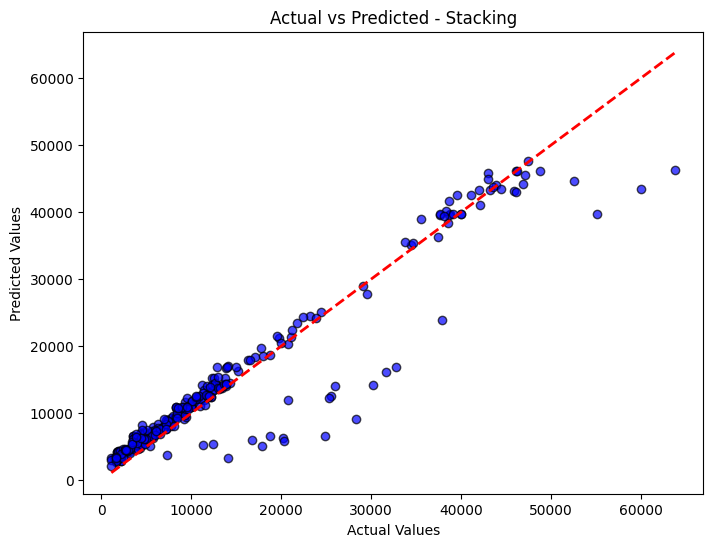

,Actual,Predicted
900,8688.85885,10782.788967
1064,5708.86700,7877.946732
1256,11436.73815,12021.542421
298,38746.35510,39675.564858
237,4463.20510,6998.783378
...,...,...
534,13831.11520,14379.210823
542,13887.20400,14418.512357
760,3925.75820,6421.711743
1284,47403.88000,47567.065670


In [54]:
# Actual Vs Predicted

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# Predictions
y_pred = final_best_model.predict(X_test)

# Metrics
final_metrics = {
    "Train R2": r2_score(y_train, final_best_model.predict(X_train)),
    "Test R2": r2_score(y_test, y_pred),
    "Train MSE": mean_squared_error(y_train, final_best_model.predict(X_train)),
    "Test MSE": mean_squared_error(y_test, y_pred),
}

print("Final Model Metrics:")
for k, v in final_metrics.items():
    print(f"{k}: {v:.4f}")

# Actual vs Predicted DataFrame
final_predictions_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

# Plot Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.show()

final_predictions_df

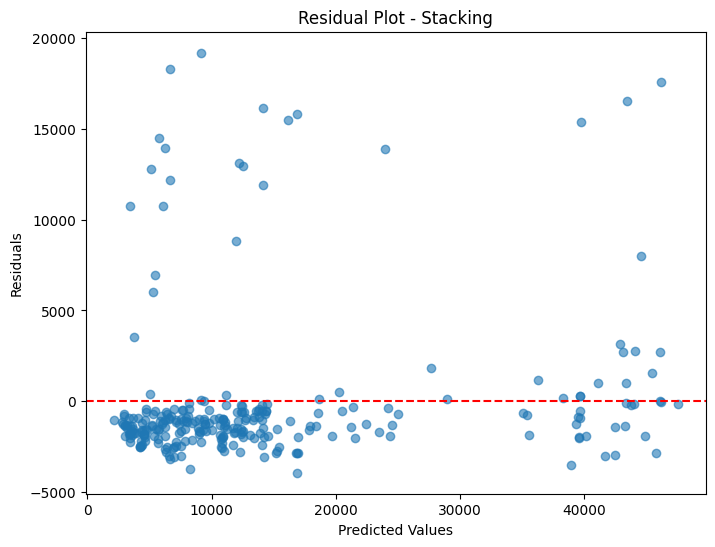

In [55]:
# Residuals plot analysis
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - {best_model_name}")
plt.show()

In [56]:
# Save Model
import joblib
joblib.dump(final_best_model, "model.pkl")
print("Model saved successfully.")

Model saved successfully.
